baseline 모델 구축

In [ ]:
!pip install catboost
!pip install imblearn

In [ ]:
import os
import pyreadstat
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [ ]:

# ============================
# 1) 데이터 불러오기 (2019~2023 남성, 공복혈당 <126)
# ============================
folder_path = r"C:\Users\knw19\OneDrive\바탕 화면\HN13-23"
dfs = []

for y in range(2019, 2024):  # 2019~2023
    f = os.path.join(folder_path, f"HN{str(y)[-2:]}_ALL.sav")
    if not os.path.exists(f):
        print(f"[WARN] 파일 없음: {f}")
        continue
    df_y, meta = pyreadstat.read_sav(f)
    df_y['YEAR'] = y
    dfs.append(df_y)

if not dfs:
    raise RuntimeError("읽을 파일이 없습니다.")

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all[(df_all['sex'] == 1)].copy() #중년남성 필터링 
#& (df_all['age'] >= 40)
#df_all = df_all[pd.to_numeric(df_all['HE_glu'], errors='coerce') < 126]

# ============================
# 2) 파생변수 생성
# ============================
def calc_sleep(r): #수면시간 
    wk = r.get('BP16_1')
    we = r.get('BP16_2')
    
    # 결측 처리 (88, 99는 NaN)
    wk = np.nan if wk in [88, 99] else wk
    we = np.nan if we in [88, 99] else we
    
    try:
        # 평균 수면시간 (주중*5 + 주말*2)/7
        return (float(wk)*5 + float(we)*2)/7
    except:
        return np.nan

def calc_alc(r): #알코올 
    try:
        # 1) 빈도 → 주당 횟수
        freq_map = {1:0, 2:0.06, 3:0.25, 4:0.75, 5:2.5, 6:5.5}
        freq = freq_map.get(int(r.get('BD1_11', 0)), 0)

        # 2) 1회 음주량 (잔)
        cups = int(r.get('BD2_1', 0))  
        # BD2_1: 1=1~2잔, 2=3~4잔 ... 5=10잔 이상 
        cup_map = {1:1.5, 2:3.5, 3:5.5, 4:8, 5:10}
        cups = cup_map.get(cups, 0)

        # 3) 알코올 g
        return freq * cups * 10
    except:
        return np.nan

def calc_bmi_cat(r): #비만도(BMI) 
    bmi = r.get('HE_BMI')
    if bmi is None: # 
        try:
            h = float(r.get('HE_ht'))
            w = float(r.get('HE_wt'))
            bmi = w / (h/100)**2
        except:
            return pd.NA
    if bmi < 23: return 1
    elif bmi < 25: return 2
    else: return 3 

def create_edu(r): #교육
    edu = r.get('educ')
    if edu in [None, 8, 88, 99]:
        return np.nan
    return {3: 1, 4: 2, 5: 3}.get(edu, 4)

def calc_inc(r): #소득(4분위수)
    # 가능한 소득 컬럼 순서
    income_cols = ['incm','ho_incm','incm5','ho_incm5','incm_qurt','HINC_Q','INCOME']
    
    # 존재하는 첫 컬럼 찾기
    income_source = next((c for c in income_cols if c in r.index), None)
    if income_source is None:
        return np.nan

    inc = pd.to_numeric(r[income_source], errors='coerce')
    
    # 1~4 범위만 반환, 나머지는 NaN
    return inc if inc in [1,2,3,4] else np.nan

def calc_dyslip(df): #이상지질혈증 
    if 'DL1_dg' in df.columns:
        return (df['DL1_dg'] == 1).astype('Int64')
    else:
        has_hchol = (df.get('HE_HCHOL') == 1)
        has_htg   = (df.get('HE_HTG') == 1)
        return (has_hchol | has_htg).astype('Int64')
    
def calc_hypertension(df):  # 고혈압
    sbp = pd.to_numeric(df.get("HE_SBP"), errors="coerce")
    dbp = pd.to_numeric(df.get("HE_DBP"), errors="coerce")
    med = pd.to_numeric(df.get("DI1_2"), errors="coerce")
    he_hp = pd.to_numeric(df.get("HE_HP"), errors="coerce")  # 고혈압 진단 여부

    return ((sbp >= 140) | (dbp >= 90) | (med.isin([1, 2, 3, 4, 5])) | (he_hp == 4)).astype("int")

def calc_cvd(row): #심혈관질환(허혈성심장질환+뇌졸중)
    ihd = any([row.get(c) == 1 for c in ['HE_IHDfh1','HE_IHDfh2','HE_IHDfh3'] if c in row])
    stroke = any([row.get(c) == 1 for c in ['HE_STRfh1','HE_STRfh2','HE_STRfh3'] if c in row])
    return int(ihd or stroke)

# ============================
# 흡연 관련 파생변수
# ============================

def compute_smoking_status(row):
    if row.get('BS3_1') in [1, 2]:          # 현재 흡연 (매일/가끔)
        return "current"
    elif row.get('BS3_1') == 3:             # 과거 흡연
        return "former"
    elif row.get('BS1_1') == 3:             # 평생 비흡연
        return "never"
    else:
        return np.nan

def compute_pack_years(row):
    pack_years = np.nan
    
    # 현재 흡연자
    if row['smoking'] == "current":
        if pd.notna(row.get('BS2_1')) and pd.notna(row.get('age')) and pd.notna(row.get('BS3_2')):
            years = row['age'] - row['BS2_1']   # 현재 나이 - 시작연령
            pack_years = (row['BS3_2'] / 20) * years
    
    # 과거 흡연자
    elif row['smoking'] == "former":
        if pd.notna(row.get('BS6_2_1')) and pd.notna(row.get('BS6_3')):   # 년 단위
            pack_years = (row['BS6_3'] / 20) * row['BS6_2_1']
        elif pd.notna(row.get('BS6_2_2')) and pd.notna(row.get('BS6_3')): # 월 단위
            years = row['BS6_2_2'] / 12
            pack_years = (row['BS6_3'] / 20) * years
    
    # 비흡연자
    elif row['smoking'] == "never":
        pack_years = 0
    
    return pack_years

df_all['smoking'] = df_all.apply(compute_smoking_status, axis=1)
df_all['pack_years'] = df_all.apply(compute_pack_years, axis=1) #흡연
df_all['sleep_hours'] = df_all.apply(calc_sleep, axis=1) 
df_all['alcohol_g_per_week'] = df_all.apply(calc_alc, axis=1)
df_all['bmi_cat'] = df_all.apply(calc_bmi_cat, axis=1) 
df_all['education'] = df_all.apply(create_edu, axis=1) 
df_all['income'] = df_all.apply(calc_inc, axis=1) 
df_all['dyslip'] = calc_dyslip(df_all) #이상지질혈증(이진 범주형)
df_all["hypertension"] = calc_hypertension(df_all) #고혈압(이진 범주형) 
df_all['cvd'] = df_all.apply(calc_cvd, axis=1) #심혈관질환(이진 범주형)

# ============================
# 일반 변수
# ============================
df_all['glucose'] = pd.to_numeric(df_all.get('HE_glu'), errors='coerce') # 공복혈당 
df_all['waist'] = pd.to_numeric(df_all.get('HE_wc'), errors='coerce') 
df_all['sbp'] = pd.to_numeric(df_all.get('HE_sbp'), errors='coerce')
df_all['dbp'] = pd.to_numeric(df_all.get('HE_dbp'), errors='coerce')
df_all['chol'] = pd.to_numeric(df_all.get('HE_chol'), errors='coerce')
df_all['tg'] = pd.to_numeric(df_all.get('HE_TG'), errors='coerce') #중성지방 
df_all['wbc'] = pd.to_numeric(df_all.get('HE_WBC'), errors='coerce') #백혈구수 
df_all['hb'] = pd.to_numeric(df_all.get('HE_HB'), errors='coerce') #헤모글로빈 
df_all['crea'] = pd.to_numeric(df_all.get('HE_crea'), errors='coerce')
df_all['glycosuria'] = df_all.get('HE_Uglu') #요당 

# ============================
# 3) 당뇨병 라벨링 함수
# ============================
def classify_diabetes(df):
    """
    1 = 당뇨병, 0 = 정상 or 전당뇨
    기준: glucose >= 126 또는 HbA1c >= 6.5% 또는 진단/치료 기록
    """
    glucose = pd.to_numeric(df.get('glucose'), errors='coerce')
    hba1c = pd.to_numeric(df.get('HE_HbA1c'), errors='coerce') if 'HE_HbA1c' in df.columns else None

    # 진단/치료 기록
    diag_cols = [c for c in ['HE_DM','HE_DMdg','DM1_dg','DM2_dg','DM3_dg','DM4_dg','DM8_dg'] if c in df.columns]
    diagnosed = df[diag_cols].eq(1).any(axis=1) if diag_cols else pd.Series(False, index=df.index)
    treat_cols = [c for c in ['HE_DMdr','HE_insulin'] if c in df.columns]
    treated = df[treat_cols].eq(1).any(axis=1) if treat_cols else pd.Series(False, index=df.index)

    lab_cond = pd.Series(False, index=df.index)
    if glucose is not None:
        lab_cond = lab_cond | (glucose >= 126)
    if hba1c is not None:
        lab_cond = lab_cond | (hba1c >= 6.5)

    y = (diagnosed | treated | lab_cond).astype(int)
    return y

df_all['diabetes_label'] = classify_diabetes(df_all)
df_all = df_all.dropna(subset=['diabetes_label']) #결측 제거 

In [ ]:
# ============================
# 4) 모델링용 X, y
# ============================
feature_cols = ['age','income','education','pack_years','alcohol_g_per_week','waist','sbp','dbp','chol','tg','wbc','hb','crea',
                'dyslip','sleep_hours','bmi_cat', 'cvd', 'hypertension', 'glycosuria', 'glucose']
#공복혈당, 요당 포함여부 결정해야할듯

X = df_all[feature_cols]
y = df_all['diabetes_label'].astype(int)

# ============================
# 5) 학습/검증 분할
# ============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# ============================
# 6) 전처리
# ============================
cat_cols = ['income', 'education'] 
log_cols = [c for c in ['alcohol_g_per_week','chol','wbc'] if c in X.columns]
num_cols = [c for c in X.columns if c not in log_cols + cat_cols]

def safe_log1p(a): #(논문 참고: log1p 변환 대상)
    a = np.asarray(a, dtype=float)
    a[a < 0] = np.nan
    return np.log1p(a)

# 로지스틱 전처리기 (로그변환+표준화+더미화)
logistic_pre = ColumnTransformer(
    transformers=[
        # 로그+스케일
        ('log', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('log1p', FunctionTransformer(safe_log1p, feature_names_out='one-to-one')),
            ('sc', StandardScaler()),
        ]), log_cols),

        # 연속형/순서형 + 이진 범주형
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler()),
        ]), num_cols),

        # 명목형 범주형(더미변수화)
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), cat_cols),
    ],
    remainder='drop'
)

#트리형 전처리기 
tree_pre = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols), 
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

In [ ]:
# ============================
# 7) 모델 구현 
# ============================
# ============================
# logistic reg
# ============================
log_clf = Pipeline([
    ('pre', logistic_pre),
    ('log', LogisticRegression(penalty="l2", max_iter=1000, class_weight='balanced', solver='saga'))
]) # Ridge 릿지 회귀 적용 
log_clf.fit(X_train, y_train)

# ============================
# tree model 
# ============================

#randomforest
rf_clf = Pipeline(steps=[
    ("preprocessor", tree_pre),
    ("rf", RandomForestClassifier(
        n_estimators=500, random_state=42, class_weight="balanced"
    ))
])
rf_clf.fit(X_train, y_train)

#xgboost 
xgb_clf = Pipeline(steps=[
    ("preprocessor", tree_pre),
    ("xgb", XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    ))
])
xgb_clf.fit(X_train, y_train)

#catboost
cat_clf = Pipeline(steps=[
    ("preprocessor", tree_pre),
    ("cat", CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=4,
        eval_metric="AUC",
        random_seed=42,
        verbose=False
    ))
])
cat_clf.fit(X_train, y_train)

# ============================
# 8) 평가 함수
# ============================
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    print(f"===== {name} =====")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
    print(f"F1-score: {f1_score(y_test, y_pred):.4f}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    print("\n")

# ============================
# 9) 결과 표
# ============================

evaluate_model("Logistic regression", log_clf, X_test, y_test)
evaluate_model("Random Forest", rf_clf, X_test, y_test)
evaluate_model("XGBoost", xgb_clf, X_test, y_test)
evaluate_model("CatBoost", cat_clf, X_test, y_test)

c:\Users\knw19\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:51:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== Logistic regression =====
ROC-AUC: 0.8814
F1-score: 0.7076
Accuracy: 0.8424
Classification Report:
              precision    recall  f1-score   support

           0      0.921     0.865     0.892      2209
           1      0.652     0.774     0.708       722

    accuracy                          0.842      2931
   macro avg      0.786     0.819     0.800      2931
weighted avg      0.855     0.842     0.847      2931



===== Random Forest =====
ROC-AUC: 0.8929
F1-score: 0.7397
Accuracy: 0.8946
Classification Report:
              precision    recall  f1-score   support

           0      0.885     0.988     0.934      2209
           1      0.944     0.608     0.740       722

    accuracy                          0.895      2931
   macro avg      0.915     0.798     0.837      2931
weighted avg      0.900     0.895     0.886      2931



===== XGBoost =====
ROC-AUC: 0.8867
F1-score: 0.7416
Accuracy: 0.8918
Classification Report:
              precision    recall  f1-score  

변수 영향력 확인

In [204]:
# ============================
# 1) 로지스틱 회귀 변수 영향력 (OR 및 회귀계수)
# ============================
# 전처리 후 실제 feature 이름 가져오기
log_feat_names = log_clf.named_steps['pre'].get_feature_names_out()
log_model = log_clf.named_steps['log']

# coef 시리즈 생성
coef = pd.Series(log_model.coef_[0], index=log_feat_names)
OR = np.exp(coef).sort_values(ascending=False)

print("\n===== Logistic Regression OR (Top 10) =====")
print(OR.head(10).round(3))
print("\n===== Logistic Regression OR (Bottom 10) =====")
print(OR.tail(10).round(3))


===== Logistic Regression OR (Top 10) =====
num__glucose       9.847
num__glycosuria    1.661
num__waist         1.321
num__age           1.268
num__crea          1.155
cat__income_3.0    1.146
cat__income_2.0    1.133
num__tg            1.133
num__dyslip        1.091
log__wbc           1.086
dtype: float64

===== Logistic Regression OR (Bottom 10) =====
log__alcohol_g_per_week    0.974
num__dbp                   0.968
cat__education_2.0         0.959
cat__income_4.0            0.910
num__bmi_cat               0.903
num__sleep_hours           0.863
log__chol                  0.819
num__hb                    0.780
cat__education_3.0         0.704
cat__education_4.0         0.602
dtype: float64


In [202]:
# ============================
# 함수 정의: 트리 기반 모델 변수 중요도 출력
# ============================
def tree_feature_importance(models, X, top_n=10):
    """
    models: dict, {"모델이름": pipeline 객체}
    X: 전처리 전 원본 X (feature 컬럼 자동 매칭용)
    top_n: 상위 몇 개 변수 출력할지
    """
    for name, pipe in models.items():
        model = list(pipe.named_steps.values())[-1]   # 마지막 단계가 모델
        preprocessor = pipe.named_steps['preprocessor']
        
        # 전처리 후 feature 이름
        feat_names = preprocessor.get_feature_names_out()
        
        # 중요도 가져오기
        if hasattr(model, 'feature_importances_'):
            imp = model.feature_importances_
        else:  # CatBoost
            imp = model.get_feature_importance()
        
        imp_series = pd.Series(imp, index=feat_names).sort_values(ascending=False)
        
        print(f"\n===== {name} Feature Importance (Top {top_n}) =====")
        print(imp_series.head(top_n).round(4))
        print(f"\n===== {name} Feature Importance (Bottom 10) =====")
        print(imp_series.tail(10).round(3))

# ============================
# 모델 dict 생성
# ============================
tree_models = {
    "Random Forest": rf_clf,
    "XGBoost": xgb_clf,
    "CatBoost": cat_clf
}

# ============================
# 실행
# ============================
tree_feature_importance(tree_models, X_train, top_n=10)



===== Random Forest Feature Importance (Top 10) =====
num__glucose       0.3505
num__glycosuria    0.0738
num__waist         0.0689
num__tg            0.0583
num__hb            0.0573
num__crea          0.0556
num__age           0.0545
num__dbp           0.0529
num__sbp           0.0512
num__pack_years    0.0493
dtype: float64

===== Random Forest Feature Importance (Bottom 10) =====
cat__education_4.0    0.008
cat__income_3.0       0.008
cat__income_2.0       0.007
cat__income_4.0       0.007
cat__education_3.0    0.007
num__cvd              0.007
cat__education_nan    0.006
cat__education_2.0    0.005
num__dyslip           0.002
cat__income_nan       0.000
dtype: float64

===== XGBoost Feature Importance (Top 10) =====
num__glucose          0.4309
num__glycosuria       0.0854
num__age              0.0412
cat__education_nan    0.0346
cat__education_2.0    0.0314
num__hb               0.0291
num__sleep_hours      0.0283
num__waist            0.0280
num__crea             0.0267
num__pa

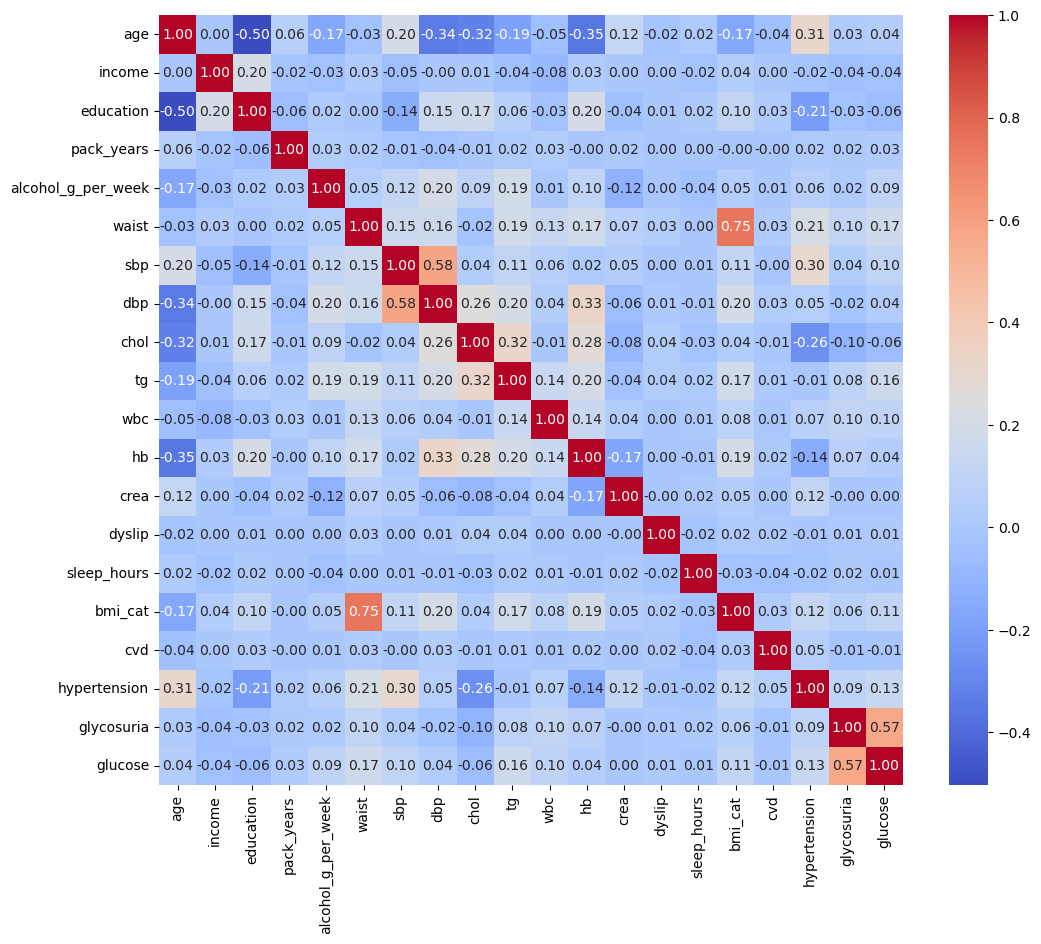

In [205]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_train.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

성능 개선

최종 model (hyperparameter tuning)

In [162]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint, loguniform

# ============================
# 하이퍼파라미터 범위 (간소화)
# ============================
cv5 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

log_space = {
    'log__C': loguniform(1e-2, 1),   # [0.01 ~ 1] 좁혀서 탐색
    'log__penalty': ['l2']
}

rf_space = {
    'rf__n_estimators': randint(100, 200),
    'rf__max_depth': randint(5, 15),
    'rf__min_samples_split': randint(2, 8),
    'rf__min_samples_leaf': randint(1, 4),
    'rf__max_features': ['sqrt', 'log2']
}

xgb_space = {
    'xgb__learning_rate': uniform(0.03, 0.2),
    'xgb__max_depth': randint(3, 8),
    'xgb__n_estimators': randint(100, 250),
    'xgb__subsample': uniform(0.7, 0.3),
    'xgb__colsample_bytree': uniform(0.7, 0.3),
}

cat_space = {
    "cat__depth": randint(4, 8),
    "cat__learning_rate": uniform(0.03, 0.2),
    "cat__iterations": randint(200, 600),
    "cat__l2_leaf_reg": uniform(2, 8),       # 규제
    "cat__bagging_temperature": uniform(0, 2) # 다양성 조절
}


# ============================
#  RandomizedSearchCV (n_iter 축소)
# ============================
log_search = RandomizedSearchCV(log_clf, log_space, n_iter=20, scoring='roc_auc', cv=cv5, n_jobs=-1, random_state=42)
rf_search = RandomizedSearchCV(rf_clf, rf_space, n_iter=20, scoring='roc_auc', cv=cv5, n_jobs=-1, random_state=42)
xgb_search = RandomizedSearchCV(xgb_clf, xgb_space, n_iter=20, scoring='roc_auc', cv=cv5, n_jobs=-1, random_state=42)
cat_search = RandomizedSearchCV(cat_clf, cat_space, n_iter=20, scoring='roc_auc', cv=cv5, n_jobs=-1, random_state=42)

# ============================
#  학습
# ============================
log_search.fit(X_train, y_train)
rf_search.fit(X_train, y_train)
xgb_search.fit(X_train, y_train)
cat_search.fit(X_train, y_train)

# 최적 모델
log_best = log_search.best_estimator_
rf_best = rf_search.best_estimator_
xgb_best = xgb_search.best_estimator_
cat_best = cat_search.best_estimator_

# ============================
#  평가
# ============================
evaluate_model("Logistic (tuned)", log_best, X_test, y_test)
evaluate_model("Random Forest (tuned)", rf_best, X_test, y_test)
evaluate_model("XGBoost (tuned)", xgb_best, X_test, y_test)
evaluate_model("CatBoost", cat_best, X_test, y_test)


c:\Users\knw19\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:51:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


===== Logistic (tuned) =====
ROC-AUC: 0.8826
F1-score: 0.7057
Accuracy: 0.8420
Classification Report:
              precision    recall  f1-score   support

           0      0.920     0.866     0.892      2209
           1      0.652     0.769     0.706       722

    accuracy                          0.842      2931
   macro avg      0.786     0.817     0.799      2931
weighted avg      0.854     0.842     0.846      2931



===== Random Forest (tuned) =====
ROC-AUC: 0.8922
F1-score: 0.7451
Accuracy: 0.8891
Classification Report:
              precision    recall  f1-score   support

           0      0.896     0.965     0.929      2209
           1      0.859     0.658     0.745       722

    accuracy                          0.889      2931
   macro avg      0.878     0.811     0.837      2931
weighted avg      0.887     0.889     0.884      2931



===== XGBoost (tuned) =====
ROC-AUC: 0.8959
F1-score: 0.7343
Accuracy: 0.8946
Classification Report:
              precision    recal

catboost model - overfitting 확인

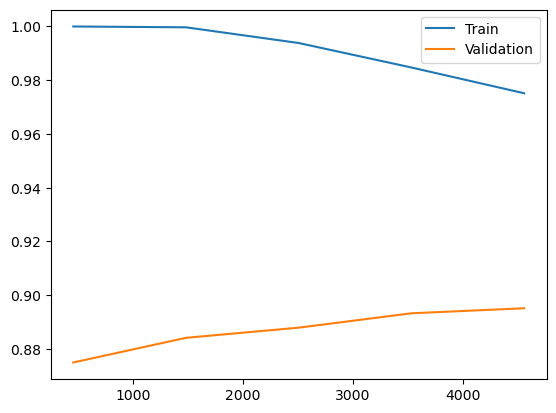

In [206]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    cat_best, X_train, y_train, cv=3, scoring="roc_auc", n_jobs=-1
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation")
plt.legend()
plt.show()


In [207]:
from sklearn.metrics import roc_auc_score

# Train 성능
train_proba = cat_best.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_proba)

# Test 성능
test_proba = cat_best.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)

print("CatBoost Train AUC:", round(train_auc, 4))
print("CatBoost Test  AUC:", round(test_auc, 4))


CatBoost Train AUC: 0.9628
CatBoost Test  AUC: 0.8892


신뢰성 검증 (brier score & calibration plot)


=== Logistic (tuned) ===
Brier Score: 0.1054


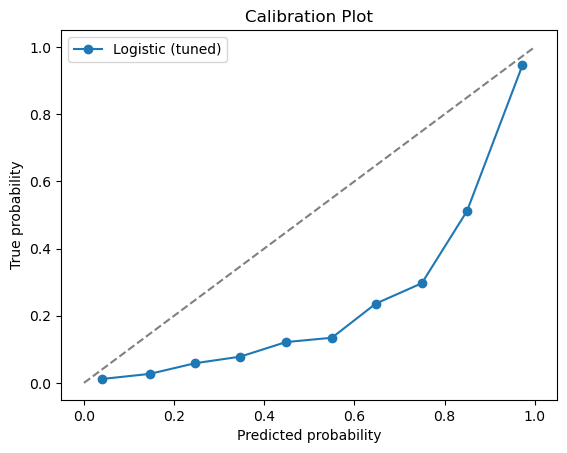


=== Random Forest (tuned) ===
Brier Score: 0.08


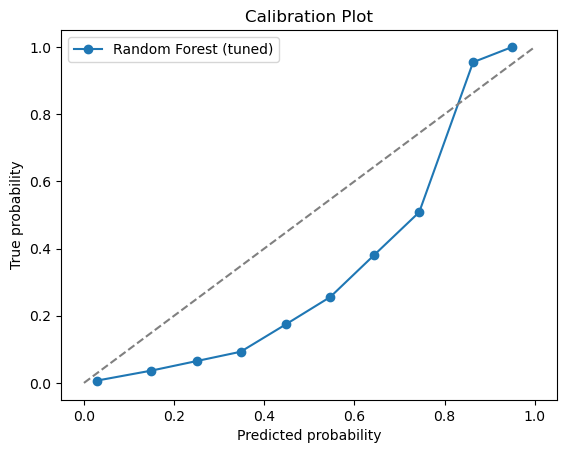


=== XGBoost (tuned) ===
Brier Score: 0.0526


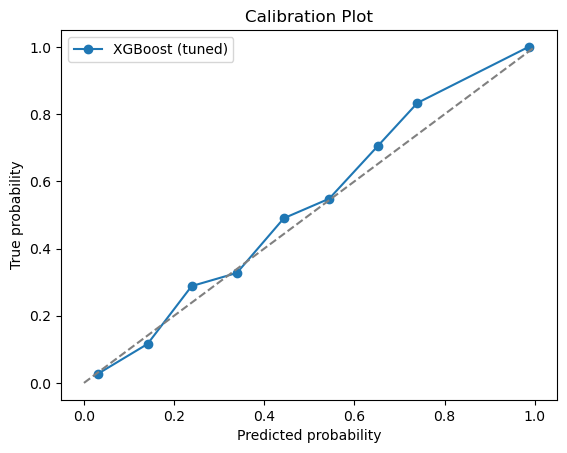


=== CatBoost ===
Brier Score: 0.0528


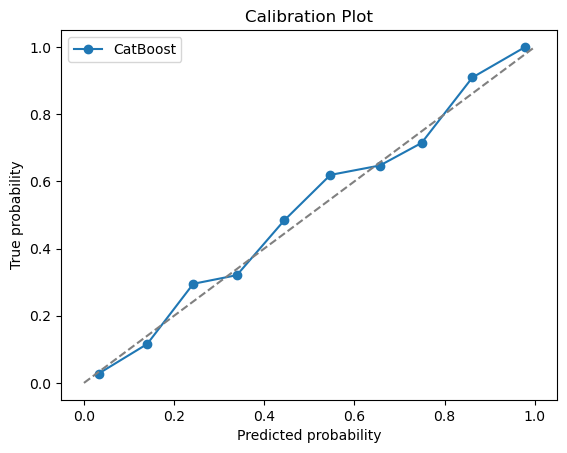

In [146]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

def calibration_analysis(name, model, X_te, y_te, n_bins=10):
    proba = model.predict_proba(X_te)[:,1]
    pred  = (proba >= 0.5).astype(int)

    # ✅ Brier Score
    brier = brier_score_loss(y_te, proba)
    print(f"\n=== {name} ===")
    print("Brier Score:", round(brier, 4))

    # ✅ Calibration Curve
    prob_true, prob_pred = calibration_curve(y_te, proba, n_bins=n_bins, strategy='uniform')

    plt.plot(prob_pred, prob_true, marker='o', label=name)
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel("Predicted probability")
    plt.ylabel("True probability")
    plt.title("Calibration Plot")
    plt.legend()
    plt.show()

# =======================
# 실행 (Best Model들)
# =======================
calibration_analysis("Logistic (tuned)", log_best, X_test, y_test)
calibration_analysis("Random Forest (tuned)", rf_best, X_test, y_test)
calibration_analysis("XGBoost (tuned)", xgb_best, X_test, y_test)
calibration_analysis("CatBoost", cat_best, X_test, y_test)
